## Imports and Needed functions

In [1]:
import numpy as np 
import math
import itertools
from itertools import product
import statistics as stats
import string
from scipy.stats import sem
import matplotlib.pyplot as plt
from matplotlib import rc

#Change if aborted reads
stop_read = 1000
###########################################################
## Plate Reader data to dictionary data 

def PR_2_dicts(dataFile,numRows,numCols):
    ''' 
    Each data (text) file can have several measurement types, 
    so data for each measurement
    will be returned in its own dictionary. 
    Also, depending on which plate reader was used, the data
    files are formatted slightly differently. 
    So this code can handle both formats. 
    '''

    # generating the labels
    row_keys = list(string.ascii_uppercase[0:numRows])
    col_keys = range(1,numCols+1)

    cartprod = list(product(row_keys,col_keys))

    well_keys = []
    for i in cartprod:
        well_keys.append(str(i[0]+str(i[1])))

    dataRead = open(dataFile)

    count = 0
    
    ReadsLine = [] # get the line in which the number of reads appears. 
    
    TimeList = []  # where 'Time' appears in the data file is where data 
                   # starts (except the first appearance), and where 
                   # 'Results' appears is where the data ends. 
            
    for line in dataRead:
        if 'Reads' in line: 
            ReadsLine.append(line)
        if 'Time' in line:
            TimeList.append(count) 
        if 'Results' in line:
            TimeList.append(count) 
        count += 1

    Reads = [] # getting the number of reads
    for word in ReadsLine[0].split():
        if word.isdigit():
            Reads.append(int(word))

    dataFinal = [] 
    
    # print(Reads)
    
    # need to properly define where the different measurements start and end
    ''' Example: If you have a file that has contains the following 
        readouts (OD600, GFP, BFP, RFP) then we have 4 measurements. 
    ''' 
    for k in range(1,len(TimeList)-1):
        
        ''' If for some reason you only want 
            a subset of the measurements in the 
            data dictionary, then you can uncomment 
            and adjust the code below
        '''
        # if k > num_measurements: 
        #     break
        
        if k == (len(TimeList) - 2):
            dataStart = TimeList[k]
            dataEnd = TimeList[k+1] - 1
        else:
            dataStart = TimeList[k]
            dataEnd = TimeList[k+1] - 4

        dataRead = open(dataFile) 

        # creating a list of the data
        count = 0 
        data = []
        for line in dataRead:
            if count >= dataStart and count <= dataEnd:
                data.append(line)
            count += 1

        # formatting the data appropriately and replacing 'OVRFLW' by 100000.0
        for i in range(len(data)):
            data[i] = data[i].split('\t') # new element in each line after tab
            data[i][-1] = data[i][-1].strip() # get rid of '\n' at end of each line
            data[i] = data[i][2:] # don't want the time and temp elements
            data[i] = ' '.join(data[i]).split() # remove the empty strings 
            if 'OVRFLW' in data[i]:
                for series in range(0,len(data[i])): 
                    if data[i][series] == 'OVRFLW':
                        data[i][series] = 100000.0
            if 'Results' in data[i]:
                break
            

        # removing all empty lists
        data = [x for x in data if x != []]
        
        # convert to floats and removes the first list that contains all the well labels
        # Note : each row contains a snapshot for some time, 
        #        and each column contains the trajectory of a single variable
        
        # print(data)
        
        # define a stop_read if we don't care about the data past a read number
        # Note: this is necessary if the plate reader run is aborted before the
        # pre-set end time
        data = np.array(data[1:stop_read], dtype=np.float64) 

        # assign the key-value pairs to a dictionary
        data_dict = {}
        for i in range(len(well_keys)):
            data_dict[well_keys[i]] = data[:,i:i+1]


        dataFinal.append(data_dict)
        
    ## Sanity check
    print('length of data_Final',len(dataFinal))
    print('length of dataFinal[0].keys()',len(dataFinal[0].keys()))
    print('shape of data', np.shape(data))
    
        
    return dataFinal,Reads[0]

#############################################################################
''' Data Analysis Functions'''
#############################################################################


''' min and max vectors through time for plate reader data
    - works off of the data arrays created by the function
      "create_data_arrays"
inputs:  data_array (num_time_pts by num_samples matrix)
        
outputs: min_data (num_time_pts by 0 vector)
         max_data (num_time_pts by 0 vector)
'''
def variability_min_max(data_array):
    
    num_time_pts, num_samples = np.shape(data_array)
    
    # initalize variability errorbars
    max_data = np.zeros((num_time_pts,))
    min_data = np.zeros((num_time_pts,))

    ## Compute variability (min and max) errorbars

    for i in range(num_time_pts):

        min_data[i] = min(data_array[i,:])
        max_data[i] = max(data_array[i,:])
            
                
    return min_data, max_data

###################################################################

''' Compute the mean, standard deviation, and standard error
    for multiple samples in time. 
    - works off of the data arrays created by the function
      "create_data_arrays"
inputs:  data_array (num_time_pts by num_samples matrix)
outputs: mean_vector (num_time_pts, 1 array)
         std_vector  (num_time_pts, 1 array)
         sem_vector  (num_time_pts, 1 array)
    Note: Every element of each output vector will be that 
    statistical measurement for that given point in time
'''

def get_stats(data_array):
    # compute sample stats in time

    # average at each time point
    mean_vector = np.zeros((num_time_pts, 1))

    # standard deviation at each time point
    std_vector = np.zeros((num_time_pts, 1))

    # standard error at each time point
    sem_vector = np.zeros((num_time_pts, 1))

    for i in range(num_time_pts):
        mean_vector[i] = stats.mean(data_array[i,:])
        std_vector[i] = np.std(data_array[i,:])
        sem_vector[i] = sem(data_array[i,:])


    mean_vector = np.reshape(mean_vector, (num_time_pts,))       
    std_vector =  np.reshape(std_vector, (num_time_pts,))  
    sem_vector =  np.reshape(sem_vector, (num_time_pts,))  
    
    return mean_vector, std_vector, sem_vector

###################################################################

''' Make data arrays from selected samples
    to be used for error bars and statistical analysis

inputs: num_time_pts     (integer)
        final_well_key   (string)
        GFP              (dictionary)
        od               (dictionary)
outputs: GFP_array       (num_time_pts by num_samples matrix)
         OD_array        (num_time_pts by num_samples matrix)
         GFP_on_OD_array (num_time_pts by num_samples matrix)
'''
def create_data_arrays(num_time_pts, final_well_key, readout, od):
    
    # initalize arrays
    readout_array = np.zeros((num_time_pts, 1))
    OD_array = np.zeros((num_time_pts, 1))
    readout_on_OD_array = np.zeros((num_time_pts, 1))
    temp = np.zeros((num_time_pts, 1))
    
    for each in od.keys():
        
        # appends columns to arrays
        readout_array = np.append(readout_array, readout[each], axis=1)
        OD_array = np.append(OD_array, od[each], axis=1)
        
        # initialize temp vector for GFP/OD
        temp = np.empty((num_time_pts, 1))
        
        for i in range(num_time_pts):
            temp[i] = readout[each][i] / (od[each][i] + 1.)
            
        # appends columns to array   
        readout_on_OD_array = np.append(readout_on_OD_array, temp, axis=1)
        
        if each == final_well_key:
            break
        
    # removes first columns of all zeros from arrays
    readout_array = readout_array[:, 1:]
    OD_array = OD_array[:,1:]
    readout_on_OD_array = readout_on_OD_array[:, 1:]
    
        
    return readout_array, OD_array, readout_on_OD_array

## USER INPUTS NEEDED - Load Data

In [68]:
''' Specify all of the following: 
    - datafile
    - numRows
    - numCols
    - sampling_rate
    
    Note: A 96 well-plate has 8 rows labelled A through H
          and 12 columns labelled 1 through 12. 
          You must know the plate reader set up to enter this info
          This info as well as the sampling rate can most likely be 
          gathered from the dataFile itself, so open it up and take
          a look if need be. 
'''

# Get data from files
dataFile = 'KC_X9_5.25.25_col9.txt'
numRows = 8
numCols = 12
sampling_rate = 4 # minutes


data,numReads = PR_2_dicts(dataFile,numRows,numCols)
# data3,numReads = PR_2_dicts(dataFile3,numRows,numCols)

print(numReads)

mcherry = data[0]

BFP = data[1] 

GFP = data[2]

od = data[3] 

# ensures that the number of reades is equal to the number
# of reads actually obtained from plate reader

# print(GFP['A1'].shape[0])
if mcherry['A1'].shape[0] != numReads:
    numReads = mcherry['A1'].shape[0]

# time vector represented in minutes
tSpan = np.linspace(0,numReads*sampling_rate,numReads)/60 



length of data_Final 4
length of dataFinal[0].keys() 96
shape of data (361, 74)
361


## GFP

dict_keys(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10', 'G11', 'G12', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12'])


Text(0, 0.5, 'fluoresence')

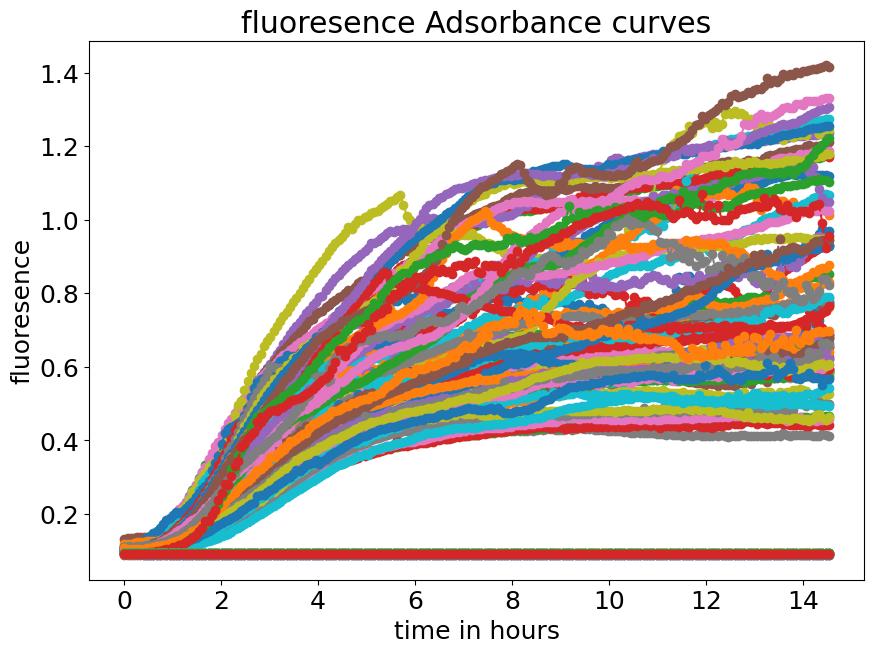

In [3]:
fluoresence = od
# Prints the keys because the keys maybe different from the wells which 
# actually contained samples in the plate reader experiment
print(fluoresence.keys())

# Plots mcherry600 curves
plt.rcParams.update({'font.size':18})
plt.figure(figsize=(10,7));
for each in fluoresence.keys():
    plt.plot(tSpan,fluoresence[each],'--o',ms=6);
plt.title(r'fluoresence Adsorbance curves')
plt.xlabel('time in hours')
plt.ylabel('fluoresence')

## OD-normalized GFP

Text(0, 0.5, 'GFP / OD 600')

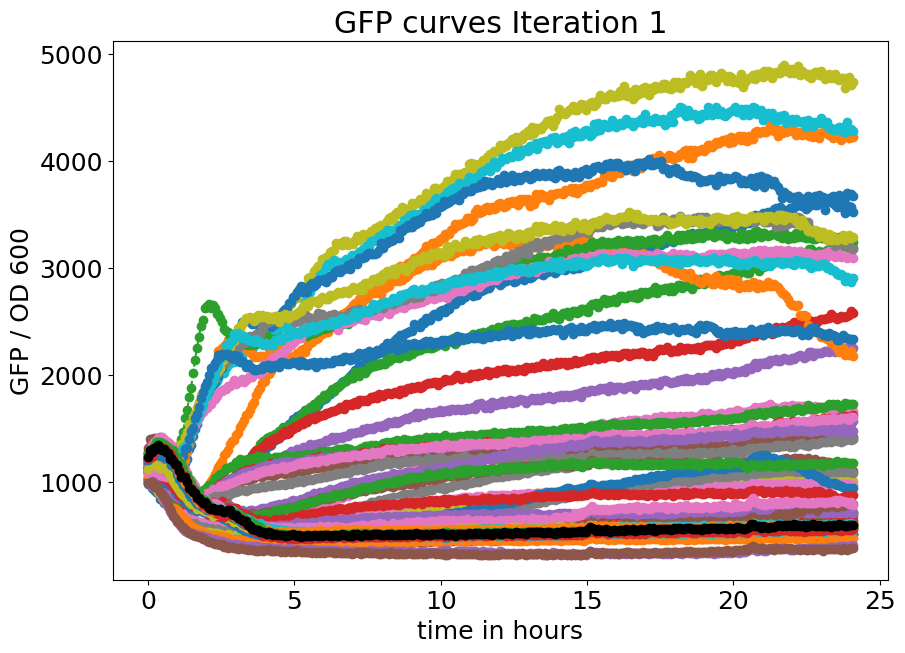

In [53]:
fluoresence = GFP
# ensures that the number of reades is equal to the number
# of reads actually obtained from plate reader


if fluoresence['A1'].shape[0] != numReads:
    numReads = fluoresence['A1'].shape[0]

# Plots GFP/OD 
plt.figure(figsize=(10,7));
for each in od.keys():
    plt.plot(tSpan,fluoresence[each]/(od[each] + 1.),'--o',ms=6); # with fudge factor
    # plt.plot(tSpan,mcherry[each]/(od[each]),'--o',ms=6); # no fudge factor
# plt.title(r'Dh5$\alpha$ with HPL plasmid')

plt.plot(tSpan,fluoresence['G2']/(od['G2'] + 1.),'--o',ms=6, color='grey', label='MG 1655 Delta LacI WT');
plt.plot(tSpan,fluoresence['G1']/(od['G1'] + 1.),'--o',ms=6, color='dimgrey', label='MG 1655 Delta LacI WT 2');
plt.plot(tSpan,fluoresence['D12']/(od['D12'] + 1.),'--o',ms=6, color='black', label='No inducer');
plt.title("GFP curves Iteration 1")
plt.xlabel('time in hours')
plt.ylabel('GFP / OD 600')

## Plot single sample

Text(0, 0.5, 'GFP / OD600')

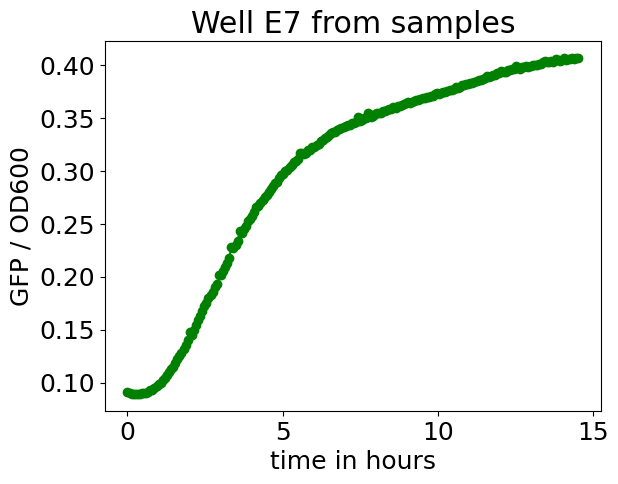

In [5]:
well = 'E7'

plt.plot(tSpan,od[well]/(od[well]+1),'--o', c = 'g', ms=6);
plt.title('Well ' + str(well) + ' from samples')
plt.xlabel('time in hours')
plt.ylabel('GFP / OD600')

## Plot GFP and OD array

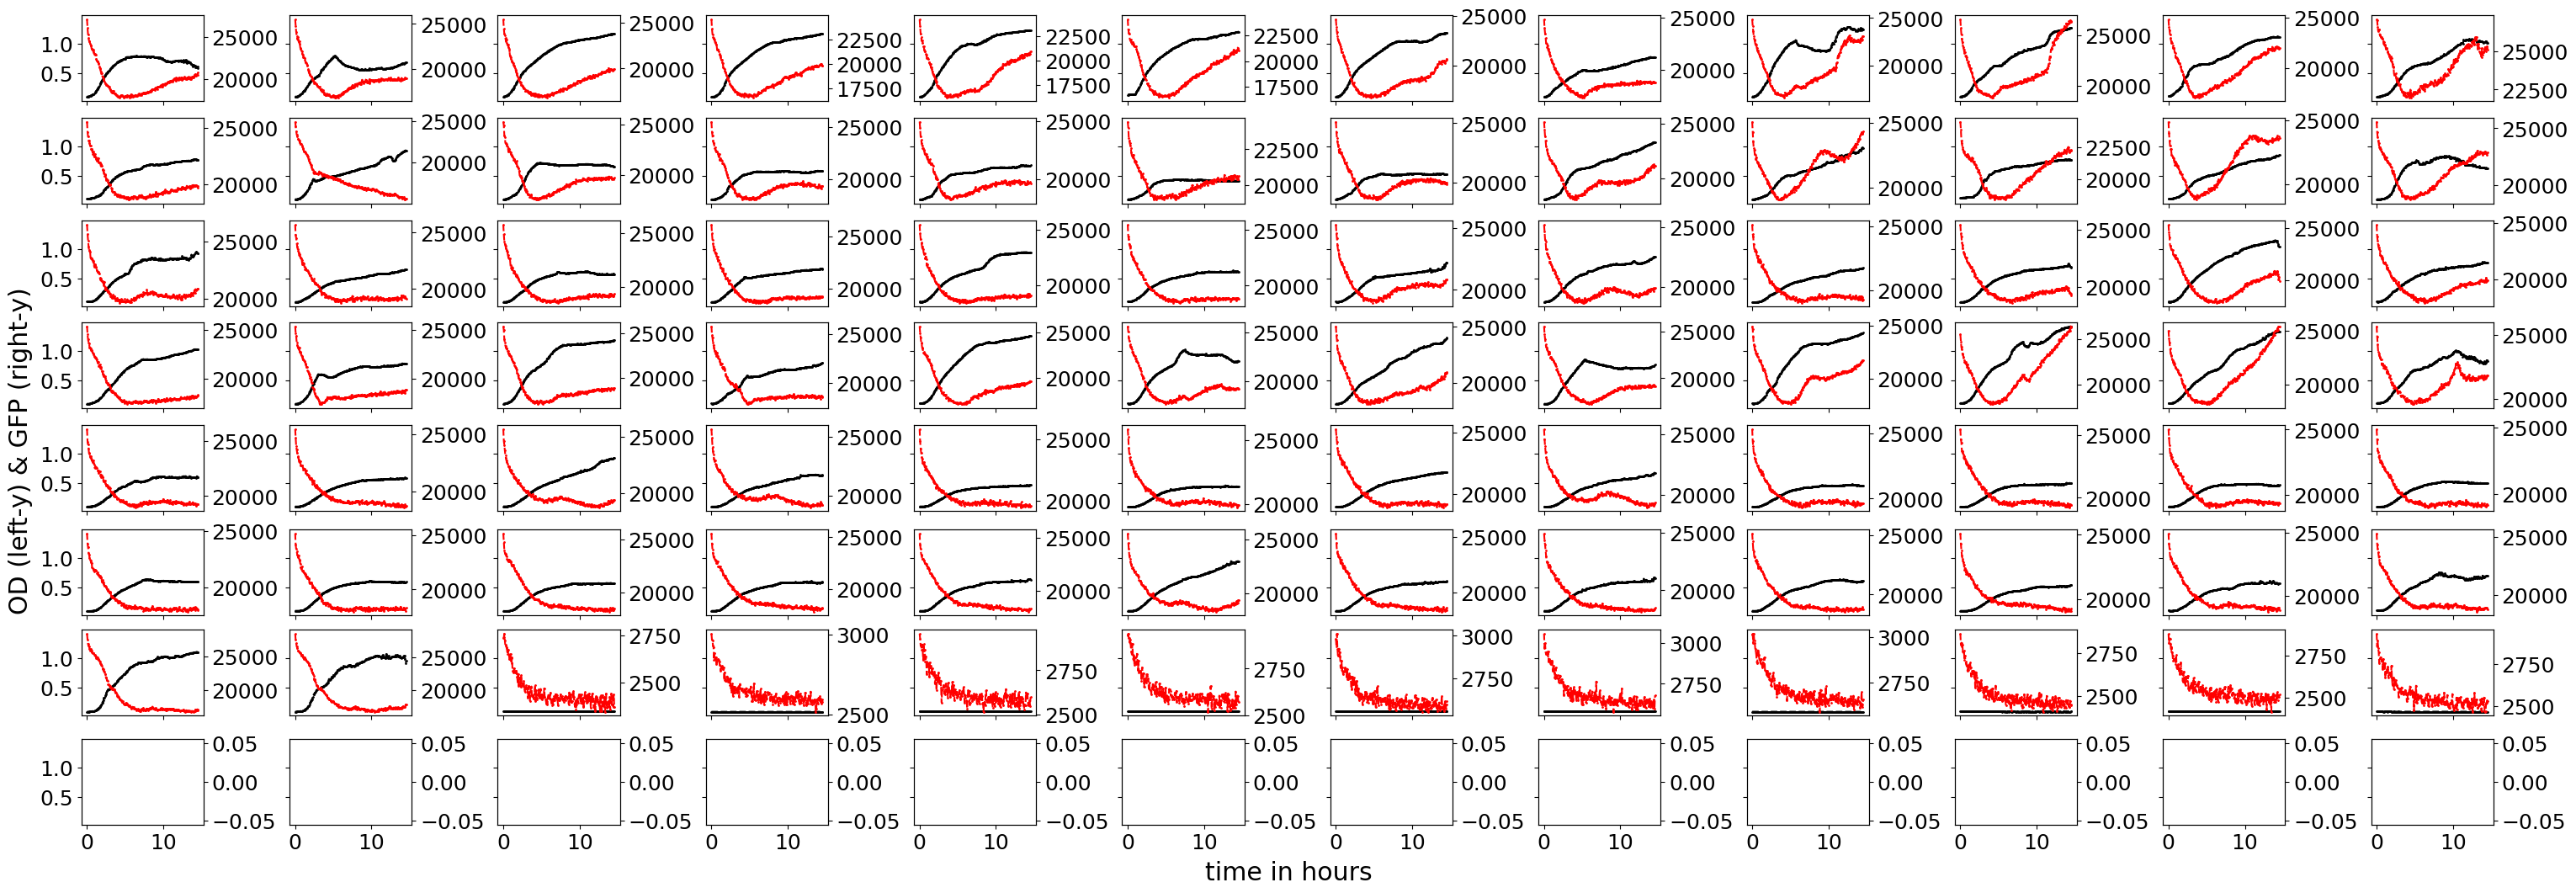

In [6]:
fluoresence = BFP

M = 0 # initialize subplot number

fig, ax1 = plt.subplots(numRows, numCols, sharex = True, sharey = True, constrained_layout = True)
fig.set_size_inches(30.5, 10.5)
# fig.suptitle("JH_AN_EY_DP_OS_HPL_PCA_Plate_5")
fig.supxlabel("time in hours")
# plt.ylim([0,1000])
fig.supylabel("OD (left-y) & GFP (right-y) ")

for each in od.keys():
    
    # the correct position in the subplot array is ensured by (math.floor(M/numCols), M%numCols) 
    
    # ax1 for OD vs time
    ax1[math.floor(M/numCols), M%numCols].plot(tSpan, od[each], '--o', ms=1, color='black');
    
    # ax1 and ax2 share the same x axis values (time)
    ax2 = ax1[math.floor(M/numCols), M%numCols].twinx()
    
    # ax2 for GFP vs time
    ax2.plot(tSpan, fluoresence[each], '--o', ms=1, color='r');
    
    M = M+1 # increase index of subplot number
    
    
## Scratch work
# M = 0
# fig, ax = plt.subplots(6, 10,sharex=True, sharey=True)
# for each in od.keys():
#     ax[math.floor(M/10), M%10].plot(tSpan,GFP[each],'--o',ms=1);
#     M = M+1
    


## Select Samples for statistical analysis

Text(0, 0.5, 'BFP/OD600')

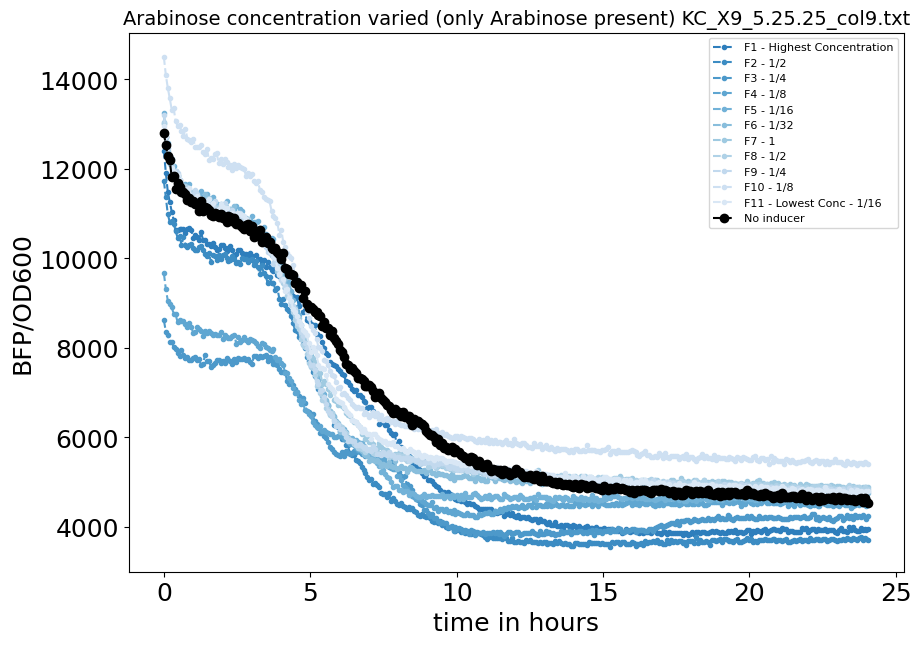

In [86]:
layout_one = {
    'A': 'Arabinose concentration varied (only Arabinose present)',
    'B': 'Arabinose concentration varied (only Arabinose present)',
    'C': 'Salicylate concentration varied (only Salicylate present)',
    'D': 'Salicylate concentration varied (only Salicylate present)',
    'E': 'HSL concentration varied (only HSL present)',
    'F': 'HSL concentration varied (only HSL present)',
    'G': 'Arabinose and Salicylate concentrations varied',
}


#inputs
layout_current = layout_one
fluoresence = BFP
row = 'a'.upper()

#Legend titles
legend = {1:"Highest Concentration", 2: "1/2", 3: "1/4", 4: "1/8", 5: "1/16", 6: "1/32", 7: "1", 8: "1/2", 9: "1/4", 10: "1/8", 11: "Lowest Conc - 1/16", 12: "No Inducer(s)"}


#Colors for graph
fluoresence_name = {id(data[0]): "mCherry", id(data[1]): "BFP", id(data[2]): "GFP", id(data[3]): "OD"}.get(id(fluoresence), "Unknown")
if fluoresence_name == "GFP":
    colors = plt.cm.Greens_r(np.linspace(0.3, 0.9, 12))  # Adjust range (0.3 to 0.9) for better contrast
elif fluoresence_name == "mCherry":
    colors = plt.cm.Reds_r(np.linspace(0.3, 0.9, 12))  # Adjust range (0.3 to 0.9) for better contrast
elif fluoresence_name == "BFP":
    colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, 12))  # Adjust range (0.3 to 0.9) for better contrast



#Plotting 
plt.figure(figsize=(10,7))
subset_keys =  [elem for elem in list(od.keys()) if elem[0] == row]  #if elem in "A"

# subset_keys = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6'] #, 'G7', 'G8', 'G9', 'G10', 'G11', 'G12'] #for testing

subset_keys = ['B7', 'B8', 'B9', 'B10', 'B11', 'B12'] #for testing Arab only
subset_keys = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6'] #for testing Sal only
subset_keys = ['C7', 'C8', 'C9', 'C10', 'C11', 'C12'] #for testing HSL only
subset_keys = ['D1','D2', 'D3', 'D4', 'D5', 'D6']  #for testing Arab only
subset_keys = ['D7','D8', 'D9', 'D10', 'D11', 'D12']  #for testing Sal only
subset_keys = ['E1', 'E2', 'E3', 'E4', 'E5', 'E6'] #for testing HSL only
subset_keys = ['E7', 'E8', 'E9', 'E10', 'E11', 'E12'] #for testing Arab only
subset_keys = ['F1', 'F2', 'F3', 'F4', 'F5', 'F6'] #for testing Sal only
subset_keys = ['F7', 'F8', 'F9', 'F10', 'F11', 'F12'] #for testing HSL only
subset_keys = ['A7', 'A8', 'A9', 'A10', 'A11', 'A12'] #for testing Sal only
subset_keys = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6'] #for testing HSL only
subset_keys = [f'F{i}' for i in range(1,12)]

#For Finer tuning of the x and y axis
# plt.xlim(10, 14)
# plt.ylim(15000, 25000)  
# legend = {
#     1: "Lowest Conc - 0 mM (A1)",
#     2: "1/1024",
#     3: "1/512",
#     4: "1/256",
#     5: "1/128",
#     6: "1/64",
#     7: "1/32",
#     8: "1/16",
#     9: "1/8",
#     10: "1/4",
#     11: "1/2",
#     12: "Highest Conc - 1 mM (A12)"
# }


for i, each in enumerate(subset_keys):

    # if int(each[1])%2 == 0: #odd columns
    #     continue 
        
    plt.plot(tSpan,fluoresence[each]/(od[each] + 1.),'--o',ms=3, label = f"{each} - {legend[int(each[1:])]}", color = colors[i])
    

#Wildtype
# plt.plot(tSpan,fluoresence['E7']/(od['E7'] + 1.),'--o',ms=6, color='grey', label='WT 1');
# plt.plot(tSpan,fluoresence['E8']/(od['E8'] + 1.),'--o',ms=6, color='dimgrey', label='WT 2');

plt.plot(tSpan,fluoresence[f'{row}12']/(od[f'{row}12'] + 1.),'--o',ms=6, color='black', label='No inducer');




#Plot Labels
plt.legend(fontsize = 8)
plt.title(f'{layout_current[row]} {dataFile}' , fontsize= 14)

# plt.title("IPTG decreasing. Preinduced IPTG")
plt.xlabel('time in hours')
plt.ylabel(fluoresence_name + '/OD600')


#sort them based on what is being diluted


Inc conc: [0, 0.0009765625, 0.001953125, 0.00390625, 0.0078125, 0.015625, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1.0]
Dec conc: [1.0, 0.504950495049505, 0.25742574257425743, 0.13366336633663367, 0.07178217821782178, 0.04084158415841584, 0.025371287128712873, 0.017636138613861384, 0.013768564356435644, 0.011834777227722772, 0.010867883663366336, 0.01038443688118812]


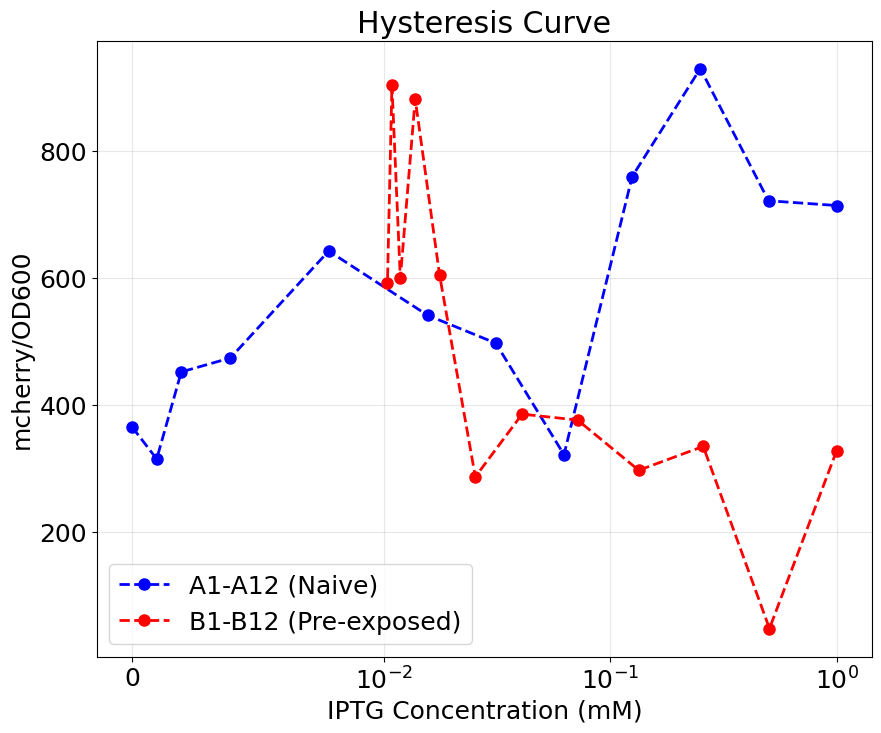

In [26]:
# Define the correct concentration mapping
# A1 = 0 mM, A12 = 1 mM (increasing)
# B1 = 1 mM, B12 = 0 mM (decreasing)
concentrations_inc = [0] + [1/2**i for i in range(10, -1, -1)]
concentrations_dec = [(1.25 + 125*(0.5)**n)/(125 + 1.25) for n in range(12)]

print("Inc conc:", concentrations_inc)
print("Dec conc:", concentrations_dec)

# Get last datapoint for each well
subset_keys_increasing = [f'A{i}' for i in range(1, 13)]
subset_keys_decreasing = [f'B{i}' for i in range(1, 13)]

last_values_increasing = {}
last_values_decreasing = {} # {"A1", od normalized}

for each in subset_keys_increasing:
    last_values_increasing[each] = mcherry[each][-1] / (od[each][-1] + 1.)
    
for each in subset_keys_decreasing:
    last_values_decreasing[each] = mcherry[each][-1] / (od[each][-1] + 1.)

# Extract values in order
values_inc = list(last_values_increasing.values())  # A1 to A12 values
values_dec = list(last_values_decreasing.values())  # B1 to B12 values

plt.figure(figsize=(10, 8))

plt.plot(concentrations_inc, values_inc, '--o', color='blue', linewidth=2, markersize=8, label='A1-A12 (Naive)')
plt.plot(concentrations_dec, values_dec, '--o', color='red', linewidth=2, markersize=8, label='B1-B12 (Pre-exposed)')

plt.xscale('symlog', linthresh=0.01)  # Linear scale for values < 0.01, log for values > 0.01
plt.xlabel('IPTG Concentration (mM)')
plt.ylabel('mcherry/OD600')
plt.title('Hysteresis Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Statistical Analysis

In [22]:
num_time_pts = numReads
final_well_key = 'H12'  # The last well key in the plate reader data
mcherry_array, OD_array, mcherry_on_OD_array = create_data_arrays(num_time_pts, 
                                                          final_well_key, 
                                                          mcherry, 
                                                          od)

min_mcherry_on_OD, max_mcherry_on_OD = variability_min_max(mcherry_on_OD_array)

mean_mcherry_on_OD, std_mcherry_on_OD, sem_mcherry_on_OD = get_stats(mcherry_on_OD_array)

ValueError: could not broadcast input array from shape (0,) into shape (1,)

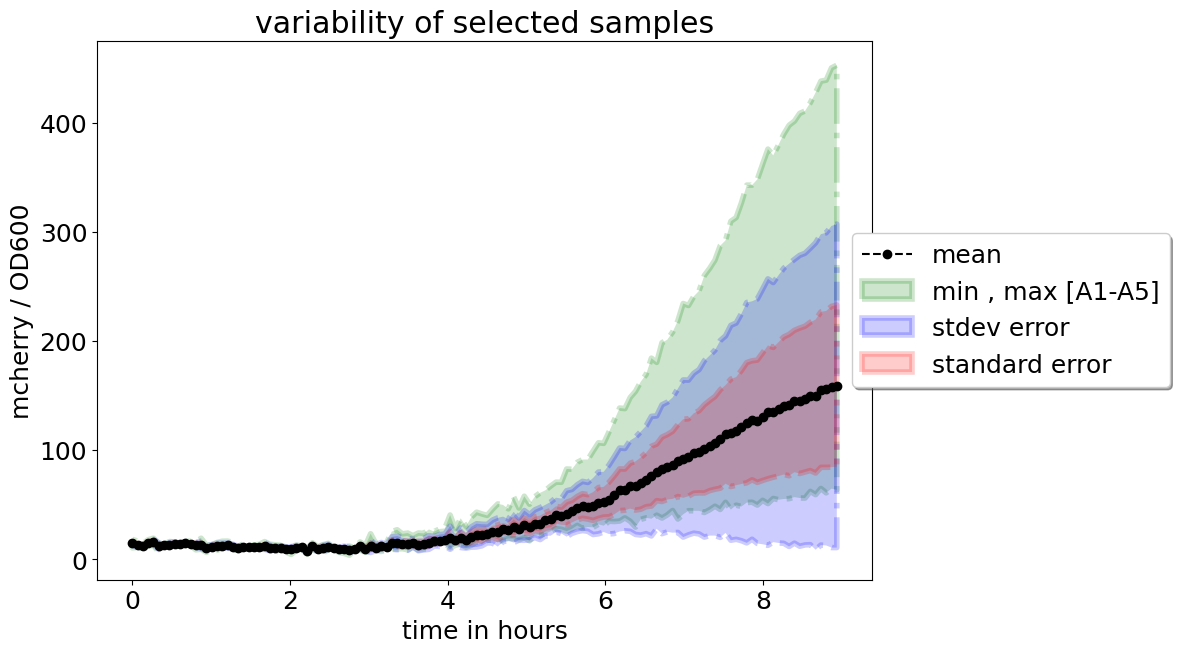

In [31]:
## Plot variability (min and max) errorbars
plt.figure(figsize=(10,7));
        
plt.plot(tSpan, mean_mcherry_on_OD, '--o', c = 'k', ms=6, label = 'mean')

plt.fill_between(tSpan, min_mcherry_on_OD, max_mcherry_on_OD,
                alpha=0.2, edgecolor='g', facecolor='g',
                linewidth=4, linestyle='dashdot', 
                label = 'min , max [A1-A5]', antialiased=True)

plt.fill_between(tSpan, 
                 np.add(mean_mcherry_on_OD, -std_mcherry_on_OD), 
                 np.add(mean_mcherry_on_OD, std_mcherry_on_OD),
                 alpha=0.2, edgecolor='b', facecolor='b',
                 linewidth=4, linestyle='dashdot', label = 'stdev error', antialiased=True)

plt.fill_between(tSpan, 
                 np.add(mean_mcherry_on_OD, -sem_mcherry_on_OD), 
                 np.add(mean_mcherry_on_OD, sem_mcherry_on_OD),
                 alpha=0.2, edgecolor='r', facecolor='r',
                 linewidth=4, linestyle='dashdot', label = 'standard error', antialiased=True)

plt.title('variability of selected samples')
plt.xlabel('time in hours')
plt.ylabel('mcherry / OD600')
plt.legend(loc='center right', bbox_to_anchor=(1.4, .5),
           ncol=1, fancybox=True, shadow=True)
